In [ ]:
# компоненты Pytorch для создания сети
from torch import flatten
from torch.nn import (Module, Conv2d, Linear, MaxPool2d,
                      ReLU, LogSoftmax)

# компоненты для обучения сети
from sklearn.metrics import classification_report
from torch.utils.data import random_split, DataLoader
from torchvision.transforms import ToTensor
from torchvision.datasets import CIFAR10
from torch.optim import Adam
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
import torch
import time

# класс классификатора, реализующий свёрточную сеть
class ConvNet(Module):
    def __init__(self, num_channels, num_classes):
        # инициализируем родительский класс
        Module.__init__(self)
        # создаём переменные для числа скрытых нейронов
        layer1_num = 32
        layer2_num = 64
        layer3_num = 128
        layer4_num = 256
        # создаём первый свёрточный слой из двумерной свёртки
        # Conv2d, нелинейного преобразования ReLU и пулинга
        # MaxPool
        self.conv1 = Conv2d(in_channels=num_channels,
                      out_channels=layer1_num,
                      kernel_size=(3, 3), padding=1)
        self.relu1 = ReLU()
        self.maxpool1 = MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
        # второй слой той же структуры, но с другим количеством признаков
        self.conv2 = Conv2d(in_channels=layer1_num,
                      out_channels=layer2_num,
                      kernel_size=(3, 3), padding=1)
        self.relu2 = ReLU()
        self.maxpool2 = MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
        # третий слой той же структуры, но с другим количеством признаков
        self.conv3 = Conv2d(in_channels=layer2_num,
                      out_channels=layer3_num,
                      kernel_size=(3, 3), padding=1)
        self.relu3 = ReLU()
        self.maxpool3 = MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
        # признаки выработаны; теперь нужен классификатор ---
        # обычный многослойный персептрон.
        # Число его входов зависит от размерности входных данных.
        # Первый полносвязный слой (и его нелинейное преобразование):
        self.fc1 = Linear(in_features=layer3_num * 4 * 4, out_features=layer4_num)
        self.relu4 = ReLU()
        # второй полносвязный слой
        self.fc2 = Linear(in_features=layer4_num, out_features=num_classes)
        # softmax для масштабирования выхода
        self.logSoftmax = LogSoftmax(dim=1)

    def forward(self, x):
        # подадим входные данные x на слои:
        # первый свёрточный слой
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.maxpool1(x)
        # второй свёрточный слой
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.maxpool2(x)
        # третий свёрточный слой
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.maxpool3(x)
        # превратим входные данные в вектор:
        x = flatten(x, 1)
        # подадим вектор на первый полносвязный слой
        x = self.fc1(x)
        x = self.relu4(x)
        # и на второй, с расчётом вероятностей
        x = self.fc2(x)
        output = self.logSoftmax(x)
        # выдадим предсказания о принадлежности к классам
        return output

# Гиперпараметры для обучения:
# скорость обучения (learning rate)
INIT_LR = 1e-3
# размер одного куска данных
BATCH_SIZE = 64
# число эпох обучения
EPOCHS = 10

# доля примеров в обучающей и валидационной части тестовой выборки
TRAIN_SPLIT = 0.75
VAL_SPLIT = 1 - TRAIN_SPLIT

# устройство, которое будет использовано для исполнения
# кода нейросетей. Если имеется видеокарта с соответствующими
# драйверами, можно выбрать "cuda" так:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Из-за возможных проблем при неверной установке
# здесь использован вариант счёта только в центральном процессоре,
# что замедляет работу в 10-30 раз, но не требует настройки видеокарты
device = torch.device("cpu")

# Пример автоматически загружает данные из выборки CIFAR-10 -
# одного из бенчмарков для отладки распознавателей:
# https://www.cs.toronto.edu/~kriz/cifar.html
print("Loading the CIFAR-10 dataset...")
trainData = CIFAR10(root="data", train=True, download=True,
    transform=ToTensor())
# загружаем тестовую выборку отдельно от обучающей
testData = CIFAR10(root="data", train=False, download=True,
    transform=ToTensor())

# выделяем в обучающей выборке валидационную часть
print("Generating the train/test split...")
numTrainSamples = int(len(trainData) * TRAIN_SPLIT)
numValSamples = int(len(trainData) * VAL_SPLIT)
# random_split распределяет примеры по выборкам
# в зависимости от генератора псевдослучайных чисел
# generator. Чтобы разделение воспроизводилось
# при каждом запуске, он инициализируется константой
(trainData, valData) = random_split(trainData,
    [numTrainSamples, numValSamples],
    generator=torch.Generator().manual_seed(17))

# Создаём объекты-загрузчики данных (класс DataLoader):
# обучающую выборку важно перемешать, иначе она будет подаваться
# на сеть в том же порядке, в каком хранится, поэтому
# для неё shuffle = True
trainDataLoader = DataLoader(trainData, shuffle=True,
    batch_size=BATCH_SIZE)
valDataLoader = DataLoader(valData, batch_size=BATCH_SIZE)
testDataLoader = DataLoader(testData, batch_size=BATCH_SIZE)
# вычислим число шагов в эпохе обучения
trainSteps = len(trainDataLoader.dataset) // BATCH_SIZE
valSteps = len(valDataLoader.dataset) // BATCH_SIZE

# инициализируем класс нейросети
print("Initializing the model...")
model = ConvNet(
    num_channels=3,
    num_classes=len(trainData.dataset.classes)).to(device)
# используем алгоритм оптимизации сети Adam
opt = Adam(model.parameters(), lr=INIT_LR)
# укажем функцию ошибок
lossFn = nn.NLLLoss()
# хранилище для истории обучения
H = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}
# запускаем обучение, начиная отсчёт времени для него
print("Training the network...")
startTime = time.time()

# для каждой эпохи
for e in range(0, EPOCHS):
    # переключить сеть в режим обучения
    model.train()
    # обнуляем счётчики ошибок обучающей и валидационной выборки
    totalTrainLoss = 0
    totalValLoss = 0
    # обнуляем счётчики правильных ответов
    trainCorrect = 0
    valCorrect = 0
    # для каждого примера в обучающей выборке
    for (x, y) in trainDataLoader:
        # передаём входные данные и правильный ответ на устройство
        (x, y) = (x.to(device), y.to(device))
        # рассчитываем выходы по переданным входным данным
        pred = model(x)
        # рассчитываем ошибку полученных выходов
        loss = lossFn(pred, y)
        # обнуляем градиенты в оптимизаторе
        opt.zero_grad()
        # выполняем обратное распространение ошибки
        loss.backward()
        # обновляем веса используемым оптимизатором
        opt.step()
        # добавляем полученную ошибку к суммарной
        totalTrainLoss += loss
        # обновляем число правильных ответов
        trainCorrect += (pred.argmax(1) == y).type(
            torch.float).sum().item()
    # Полный проход обучающей выборки закончен.
    # Отключаем автоматический расчёт градиентов (он нужен
    # только для обучения)
    with torch.no_grad():
        # переключаем модель в рабочий режим
        model.eval()
        # для каждого куска валидационной выборки
        for (x, y) in valDataLoader:
            # передать его на устройство
            (x, y) = (x.to(device), y.to(device))
            # рассчитать выход
            pred = model(x)
            # рассчитать ошибку выхода, добавить её в общую ошибку
            totalValLoss += lossFn(pred, y)
            # обновить число правильных ответов
            valCorrect += (pred.argmax(1) == y).type(
                torch.float).sum().item()
    # Прохождение обучающей и валидационной частей выборки закончено.
    # Вычислим среднюю ошибку
    avgTrainLoss = totalTrainLoss / trainSteps
    avgValLoss = totalValLoss / valSteps
    # вычисляем точность
    trainCorrect = trainCorrect / len(trainDataLoader.dataset)
    valCorrect = valCorrect / len(valDataLoader.dataset)
    # добавить данные в историю обучения
    H["train_loss"].append(avgTrainLoss.cpu().detach().numpy())
    H["train_acc"].append(trainCorrect)
    H["val_loss"].append(avgValLoss.cpu().detach().numpy())
    H["val_acc"].append(valCorrect)
    # распечатать информацию о ходе обучения
    print("Epoch {}/{}".format(e + 1, EPOCHS))
    print("Train loss: {:.6f}, Train accuracy: {:.4f}".format(
        avgTrainLoss, trainCorrect))
    print("Val loss: {:.6f}, Val accuracy: {:.4f}\n".format(
        avgValLoss, valCorrect))

# вывести общее время обучения
endTime = time.time()
print("Total time taken to train the model: {:.2f}s".format(
    endTime - startTime))
# Подаём на полностью обученную сеть тестовую выборку,
# т.е. примеры, которые раньше на сеть не подавались и
# повлиять на обучение не могли
print("Evaluating network...")
# опять отключаем вычисление градиентов
with torch.no_grad():
    # опять переводим модель в рабочий режим
    model.eval()
    # заводим список для ответов сети
    preds = []
    # для всех частей тестовой выборки
    for (x, y) in testDataLoader:
        # подаём её на устройство
        x = x.to(device)
        # вычисляем ответ сети
        pred = model(x)
        # добавляем самый вероятный ответ к списку
        preds.extend(pred.argmax(axis=1).cpu().numpy())

              precision    recall  f1-score   support

    airplane       0.75      0.78      0.77      1000
  automobile       0.86      0.82      0.84      1000
        bird       0.59      0.66      0.62      1000
         cat       0.53      0.58      0.55      1000
        deer       0.63      0.73      0.68      1000
         dog       0.72      0.53      0.61      1000
        frog       0.77      0.79      0.78      1000
       horse       0.80      0.76      0.78      1000
        ship       0.85      0.82      0.84      1000
       truck       0.82      0.79      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.73     10000
weighted avg       0.73      0.72      0.73     10000



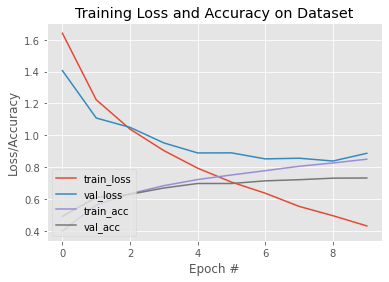

In [4]:
# Извлекаем метки классов из тестовой выборки
testLabels = [label for _, label in testData]

# распечатать отчёт о классификации
print(classification_report(testLabels,
    np.array(preds), target_names=testData.classes))

# вывести данные на графике
plt.style.use("ggplot")
plt.figure()
plt.plot(H["train_loss"], label="train_loss")
plt.plot(H["val_loss"], label="val_loss")
plt.plot(H["train_acc"], label="train_acc")
plt.plot(H["val_acc"], label="val_acc")
plt.title("Training Loss and Accuracy on Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
plt.savefig("test_res.png")
# сохранить обученную модель в файле
torch.save(model, "result_model.bin")

#              precision    recall  f1-score   support

#    airplane       0.75      0.78      0.77      1000
#  automobile       0.86      0.82      0.84      1000
#        bird       0.59      0.66      0.62      1000
#         cat       0.53      0.58      0.55      1000
#        deer       0.63      0.73      0.68      1000
#         dog       0.72      0.53      0.61      1000
#        frog       0.77      0.79      0.78      1000
#       horse       0.80      0.76      0.78      1000
#        ship       0.85      0.82      0.84      1000
#       truck       0.82      0.79      0.80      1000

#    accuracy                           0.72     10000
#   macro avg       0.73      0.72      0.73     10000
#weighted avg       0.73      0.72      0.73     10000
